
===== Random Forest =====
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       105
           1       0.75      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.78      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



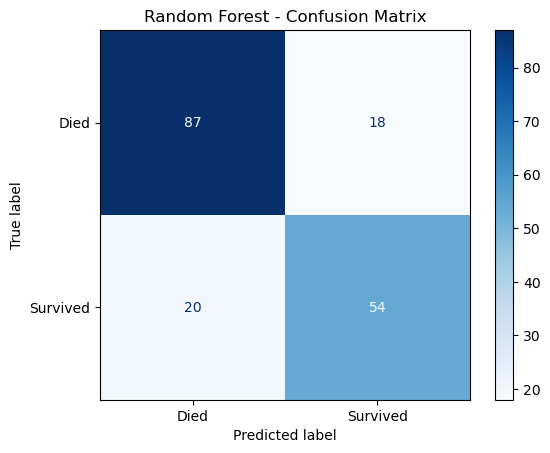

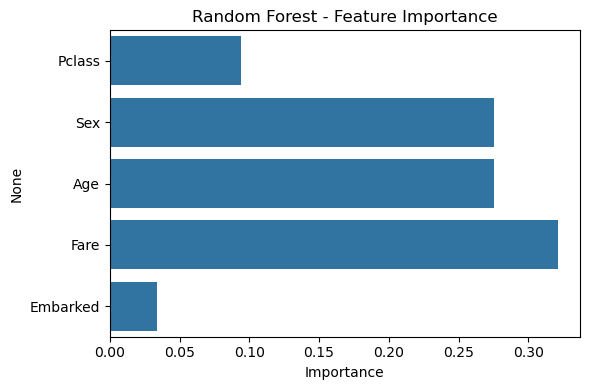


===== AdaBoost =====
              precision    recall  f1-score   support

           0       0.82      0.85      0.83       105
           1       0.77      0.73      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



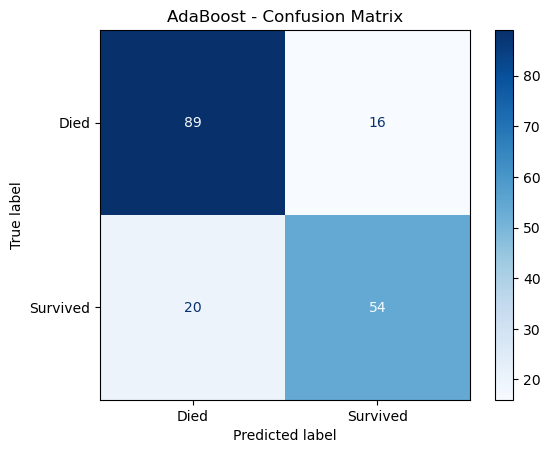

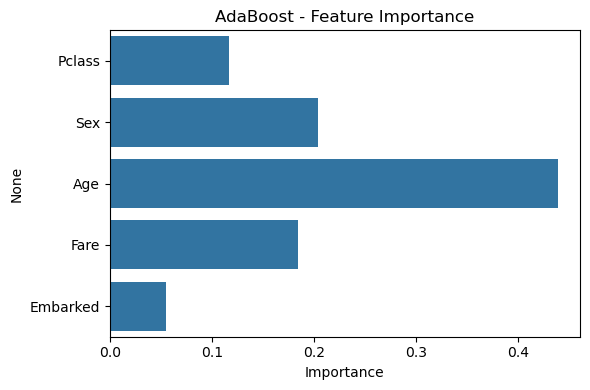


===== Gradient Boosting =====
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



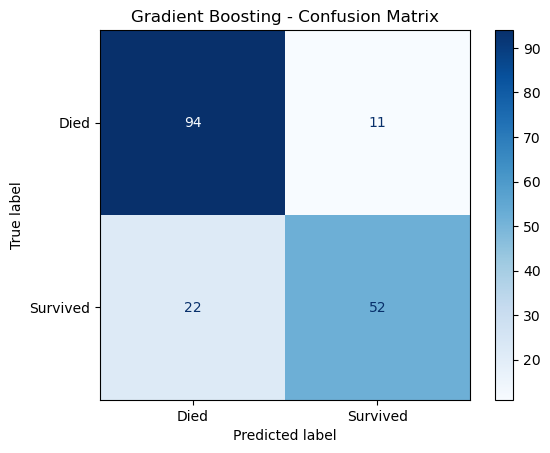

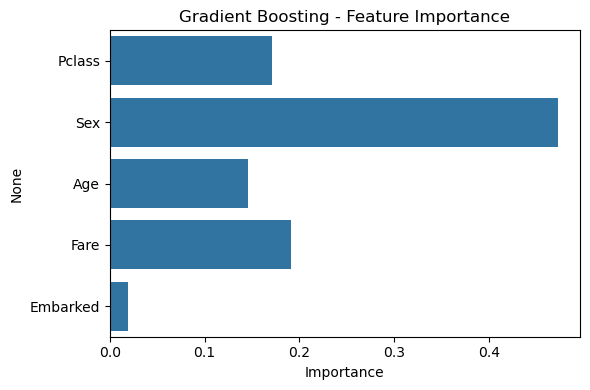

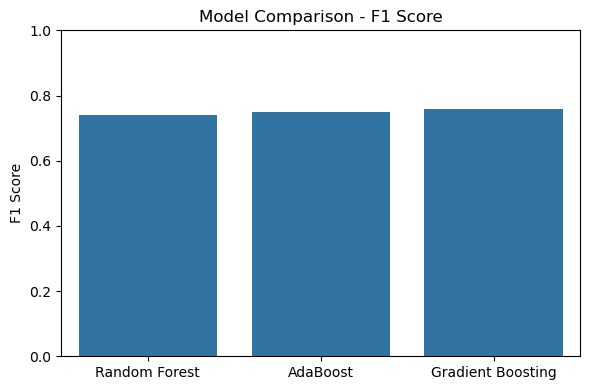

In [5]:
# Apply AdaBoost and Gradient Boosting and compare with Random Forest
# Using Confusion Matrix, Feature Importance, and F1 comparison.

# ---------------------------------------------------------
# Import libraries
# ---------------------------------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)
import matplotlib.pyplot as plt
import seaborn as sns
import os

# ---------------------------------------------------------
# Load dataset
# ---------------------------------------------------------
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

# ---------------------------------------------------------
# Feature cleaning
# ---------------------------------------------------------
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']
df = df[features + ['Survived']]

df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

for col in ['Sex', 'Embarked']:
    df[col] = LabelEncoder().fit_transform(df[col])

# ---------------------------------------------------------
# Split data
# ---------------------------------------------------------
X = df[features]
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---------------------------------------------------------
# Define models
# ---------------------------------------------------------
models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "AdaBoost": AdaBoostClassifier(n_estimators=100, algorithm="SAMME", random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Create output folder
os.makedirs("plots", exist_ok=True)

results = []

# ---------------------------------------------------------
# Train + Evaluate
# ---------------------------------------------------------
for name, model in models.items():

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append((name, acc, f1))

    print(f"\n===== {name} =====")
    print(classification_report(y_test, y_pred))

    # CONFUSION MATRIX
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Died", "Survived"])
    disp.plot(cmap="Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.savefig(f"plots/{name.replace(' ', '_').lower()}_confusion_matrix.png")
    plt.show()

    # FEATURE IMPORTANCE (if available)
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=features)

        plt.figure(figsize=(6, 4))
        sns.barplot(x=importances.values, y=importances.index)
        plt.title(f"{name} - Feature Importance")
        plt.xlabel("Importance")
        plt.tight_layout()
        plt.savefig(f"plots/{name.replace(' ', '_').lower()}_feature_importance.png")
        plt.show()

# ---------------------------------------------------------
# F1 Score Comparison Plot
# ---------------------------------------------------------
labels = [r[0] for r in results]
f1_scores = [r[2] for r in results]

plt.figure(figsize=(6, 4))
sns.barplot(x=labels, y=f1_scores)
plt.title("Model Comparison - F1 Score")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("plots/f1_score_comparison.png")
plt.show()
